# Прогнозирование цены

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные из CSV файла
try:
    df = pd.read_csv('price_sample.csv')
    print("Файл успешно загружен")
except FileNotFoundError:
    print("Файл price_sample.csv не найден. Убедитесь, что он в папке с кодом.")

# Выводим первые 5 строк, чтобы увидеть структуру (price и 4 атрибута)
print("\nПервые 5 строк данных:")
print(df.head())

# Проверяем общую информацию: типы данных и наличие пустых значений (NaN)
print("\nИнформационная сводка:")
df.info()

# Посмотрим на основные статистические показатели (среднее, минимум, максимум, квартили)
print("\nСтатистическое описание:")
print(df.describe())

Файл успешно загружен

Первые 5 строк данных:
   para1  para2    para3  para4   price
0      1  662.0   3000.0    3.8   73.49
1      1  340.0   2760.0    9.2  300.00
2      0   16.0   2700.0    3.0  130.00
3      1   17.0  12320.0    6.4  365.00
4      1  610.0   2117.0   10.8  357.50

Информационная сводка:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB

Статистическое описание:
              para1        para2         para3        para4         price
count  10003.000000  9997.000000  10003.000000  9998.000000  10003.000000
mean       1.380986   447.270681   9547.975527     8.458024    433.774924
std        3.500408   2

In [2]:
# Удаляем полные дубликаты строк, чтобы модель не "зазубривала" одинаковые примеры
df = df.drop_duplicates()

# Проверяем наличие пропущенных значений в каждом столбце
missing_values = df.isnull().sum()
print("\nПропущенные значения:\n", missing_values)

# Если есть пропуски, заполняем их медианным значением по столбцу
# Медиана лучше среднего, так как она менее чувствительна к выбросам в ценах
if missing_values.any():
    df = df.fillna(df.median())
    print("\nПропуски были заполнены медианными значениями.")


Пропущенные значения:
 para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

Пропуски были заполнены медианными значениями.


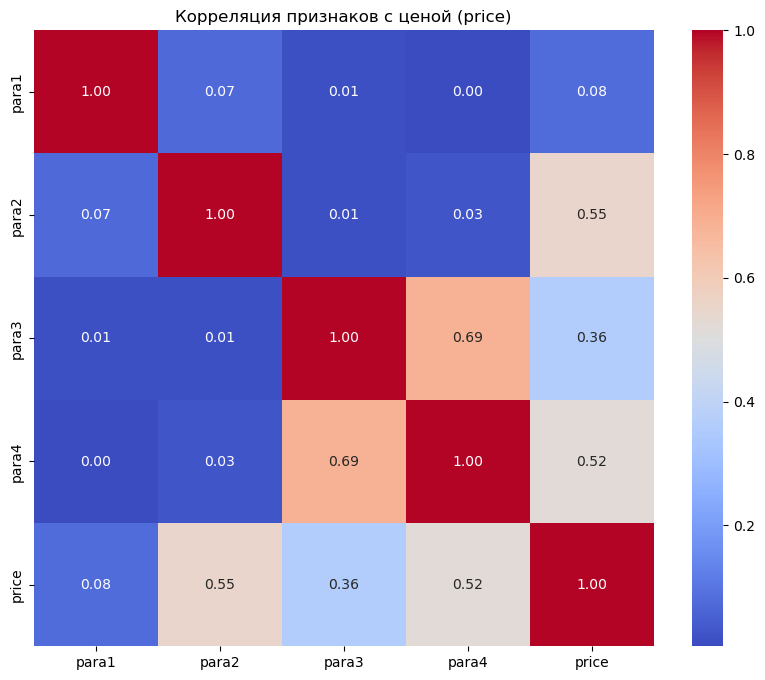

In [3]:
# Строим тепловую карту корреляции
plt.figure(figsize=(10, 8))
# Используем корреляцию Пирсона для оценки линейных связей
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков с ценой (price)')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Разделяем данные на признаки (X) и целевую переменную (y - цена)
X = df.drop('price', axis=1)
y = df['price']

# Разделяем на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем модель Случайного Леса с 100 деревьями
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Обучаем модель на тренировочных данных
model.fit(X_train, y_train)

# Делаем предсказание на тестовых данных, которые модель еще не видела
y_pred = model.predict(X_test)


Точность модели (R2 score): 0.6650
Средняя ошибка предсказания цены (MAE): 101.00


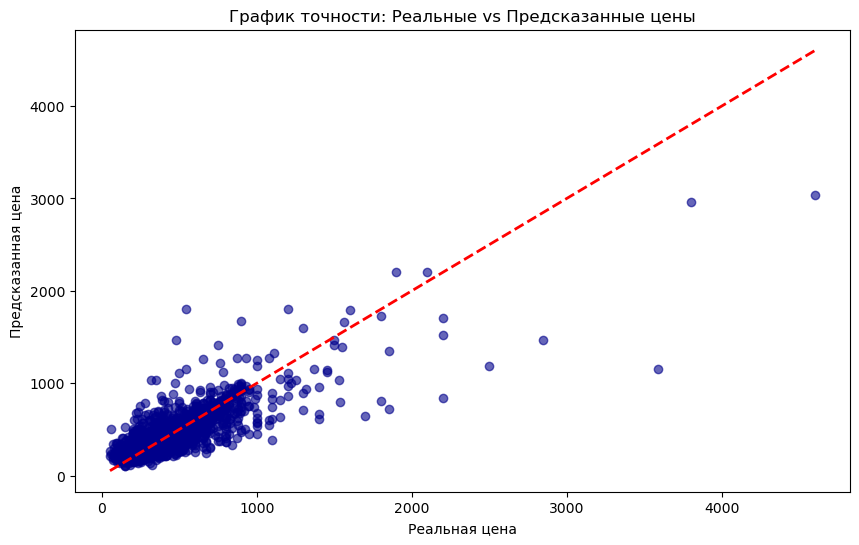

In [6]:
# Вычисляем метрики
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nТочность модели (R2 score): {r2:.4f}")
print(f"Средняя ошибка предсказания цены (MAE): {mae:.2f}")

# ГРАФИК 1: Сравнение реальных цен и предсказанных
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')
# Рисуем идеальную прямую (где предсказание равно реальности)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('График точности: Реальные vs Предсказанные цены')
plt.show()

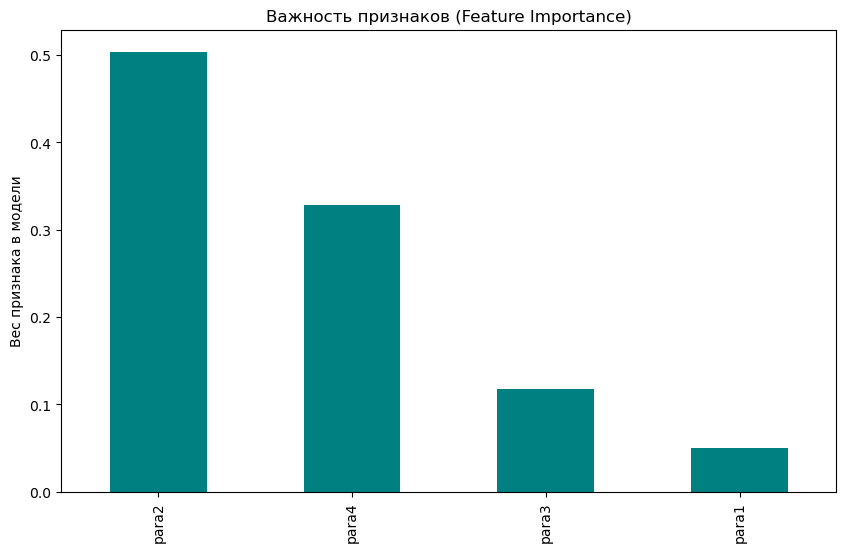

In [7]:
# Извлекаем важность признаков из модели
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='teal')
plt.title('Важность признаков (Feature Importance)')
plt.ylabel('Вес признака в модели')
plt.show()